# Bayesian Analysis

---
## 0 · Imports & Data

In [1]:
from preprocessing.pipeline import preprocess_all
from frequentist.models import VAR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from numpy.linalg import inv, cholesky
from statsmodels.tsa.vector_ar.var_model import VAR as smVAR

# ── Reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(seed=6)

In [2]:
# ── Preprocess (identical to the VAR notebook) ────────────────────────────────
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],
    diff_cols=["eui", "gpr", "cpu", "oil_price"],
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags=False,
)

features_df = artifacts["features_df"]
train_df    = artifacts["train_df"]
test_df     = artifacts["test_df"]
target_col  = "log_eui"

# Endogenous variables (log levels) — same as VAR
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

endog_train = train_df[var_endog_cols].dropna()
endog_test  = test_df[var_endog_cols]
endog_full  = pd.concat([endog_train, endog_test])

test_index = test_df.index
n_train    = len(endog_train)

print(f"Training observations : {n_train}")
print(f"Test observations     : {len(endog_test)}")
print(f"Variables             : {var_endog_cols}")


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

---
## Phase 1 · Setup and Initialisation

In [3]:
# ── Model dimensions ─────────────────────────────────────────────────────────
p = 2            # lag order — identical to the frequentist VAR
n = len(var_endog_cols)   # number of endogenous variables  (n = 4)
k = n * p + 1   # coefficients per equation: intercept + n*p lags  (k = 9)

# ── MCMC settings ────────────────────────────────────────────────────────────
N_draws  = 10_000   # total Gibbs draws per window
N_burnin =  2_000   # draws discarded as burn-in
N_keep   = N_draws - N_burnin   # = 8 000 draws used for forecasting

print(f"VAR({p})  |  n={n} variables  |  k={k} coefficients per equation")
print(f"MCMC: {N_draws} draws, {N_burnin} burn-in → {N_keep} retained")

VAR(2)  |  n=4 variables  |  k=9 coefficients per equation
MCMC: 10000 draws, 2000 burn-in → 8000 retained


For a dataset with $T$ observations and $n$ variables we build:
- $Y$ : $(T-p) \times n$ matrix of left-hand-side observations
- $X$ : $(T-p) \times (np+1)$ matrix with an intercept and $p$ lags

In [4]:
import numpy as np
from statsmodels.tsa.ar_model import AutoReg

def estimate_sigma_ar(data: np.ndarray, p: int) -> np.ndarray:
    """
    Fit a univariate AR(p) on each column of data and return the
    vector of residual standard deviations (length n).
    These are used to make the Minnesota prior scale-invariant.
    """
    n = data.shape[1]
    sigma_hat = np.empty(n)
    for i in range(n):
        res = AutoReg(data[:, i], lags=p, old_names=False).fit()
        sigma_hat[i] = np.std(res.resid)
    return sigma_hat

def build_XY(data: np.ndarray, p: int):
    """
    Build the regressor matrix X and response matrix Y for a VAR(p).

    Parameters
    ----------
    data : ndarray of shape (T, n)
        Raw time-series matrix (rows = time, columns = variables).
    p : int
        Lag order.

    Returns
    -------
    Y : ndarray (T-p, n)   — left-hand side
    X : ndarray (T-p, np+1) — right-hand side (intercept + lags)
    """
    T, n = data.shape
    rows = T - p
    X = np.ones((rows, n * p + 1))    # first column = intercept
    for lag in range(1, p + 1):
        col_start = 1 + (lag - 1) * n
        col_end   = 1 + lag * n
        X[:, col_start:col_end] = data[p - lag: T - lag, :]
    Y = data[p:, :]
    return Y, X


def get_ols_start(data: np.ndarray, p: int):
    """
    Fit a frequentist VAR(p) via OLS and return the coefficient vector
    beta_ols (shape n*k) and the residual covariance Sigma_ols (n×n).
    These serve as starting values for the Gibbs sampler.
    """
    Y, X = build_XY(data, p)
    T_eff = Y.shape[0]
    # OLS: B_hat = (X'X)^{-1} X'Y  — shape (k, n)
    B_ols   = inv(X.T @ X) @ X.T @ Y
    resid   = Y - X @ B_ols            # (T_eff, n)
    Sigma   = (resid.T @ resid) / T_eff
    beta    = B_ols.T.flatten()        # vec row-wise → length n*k
    return beta, Sigma


# Quick sanity check on initial training set
data_init = endog_train.values
beta_init, Sigma_init = get_ols_start(data_init, p)
print(f"OLS β shape : {beta_init.shape}  (n*k = {n}×{k})")
print(f"OLS Σ shape : {Sigma_init.shape}")

OLS β shape : (36,)  (n*k = 4×9)
OLS Σ shape : (4, 4)


### 1.2 Prior hyperparameters

#### No Prior Information

In [5]:
# ── Prior hyperparameters ────────────────────────────────────────────────────
# β ~ N(β₀, V_β)  — one β vector per equation stacked: total dim = n*k
beta0  = np.zeros(n * k)           # prior mean: no prior information
V_beta = np.eye(n * k)             # prior covariance: diffuse
V_beta_inv = np.eye(n * k)         # its inverse (trivial since V_beta = I)

# Σ ~ IW(ν₀, S₀)
nu0 = 6.0                          # degrees of freedom
S0  = np.eye(n)                    # scale matrix

print("Prior hyperparameters")
print(f"  β₀  : zero vector of length {n*k}")
print(f"  V_β : identity matrix ({n*k}×{n*k})")
print(f"  ν₀  : {nu0}")
print(f"  S₀  : identity matrix ({n}×{n})")

Prior hyperparameters
  β₀  : zero vector of length 36
  V_β : identity matrix (36×36)
  ν₀  : 6.0
  S₀  : identity matrix (4×4)


#### Minnesota Prior

In [6]:
def build_minnesota_prior_data_informed(
    n, p, sigma_hat, beta_ols,
    lambda1=0.2, lambda2=0.5, lambda3=1.0, intercept_var=100.0
):
    """
    Minnesota prior where the prior MEAN comes from OLS on the
    initial training set, rather than the random-walk assumption.
    This is sometimes called a 'training-sample prior' or
    'data-driven Minnesota prior'.
    """
    k  = n * p + 1
    nk = n * k

    # Start from OLS estimates rather than the random-walk assumption
    beta0  = beta_ols.copy()
    v_diag = np.zeros(nk)

    for eq in range(n):
        row_start = eq * k
        v_diag[row_start] = intercept_var   # diffuse intercept

        for lag in range(1, p + 1):
            for var in range(n):
                col = row_start + 1 + (lag - 1) * n + var
                if var == eq:
                    v_diag[col] = (lambda1 / lag ** lambda3) ** 2
                else:
                    v_diag[col] = (
                        lambda1 * lambda2 / lag ** lambda3
                        * sigma_hat[eq] / sigma_hat[var]
                    ) ** 2

    V_beta_inv = np.diag(1.0 / v_diag)
    return beta0, np.diag(v_diag), V_beta_inv

# The sweet spot given your diagnostics:
# - lambda1 in [0.1, 0.2]: enough shrinkage to matter, not so tight it dominates
# - lambda2 in [0.8, 1.0]: cross-variable effects barely shrunk since oil matters
# - prior mean = OLS estimates: eliminates the random-walk bias on L1.log_eui

sigma_hat = estimate_sigma_ar(endog_train.values, p)
beta_ols, _ = get_ols_start(endog_train.values, p)

beta0_mn, V_beta_mn, V_beta_inv_mn = build_minnesota_prior_data_informed(
    n=n, p=p,
    sigma_hat=sigma_hat,
    beta_ols=beta_ols,      # <-- prior mean anchored at OLS, not random walk
    lambda1=0.05,           # moderate tightness
    lambda2=0.5,            # cross-variable effects nearly as free as own lags
    lambda3=1.0,
    intercept_var=100.0,
)

---
## Phase 2 · Expanding-Window Gibbs Sampler

In [7]:
def run_gibbs(
    Y: np.ndarray,
    X: np.ndarray,
    beta0: np.ndarray,
    V_beta_inv: np.ndarray,
    nu0: float,
    S0: np.ndarray,
    N_draws: int,
    beta_start: np.ndarray,
    Sigma_start: np.ndarray,
    rng: np.random.Generator,
):
    """
    Run the Gibbs sampler for the BVAR.

    Parameters
    ----------
    Y, X       : response and regressor matrices (T_eff × n, T_eff × k)
    beta0      : prior mean  (n*k,)
    V_beta_inv : inverse prior covariance  (n*k × n*k)
    nu0, S0    : IW prior parameters
    N_draws    : total number of Gibbs iterations
    beta_start : starting β vector  (n*k,)
    Sigma_start: starting Σ matrix  (n × n)
    rng        : numpy random Generator

    Returns
    -------
    beta_draws  : ndarray (N_draws, n*k)
    Sigma_draws : ndarray (N_draws, n, n)
    """
    T_eff, n_ = Y.shape
    k_        = X.shape[1]
    nk        = n_ * k_

    beta_draws  = np.empty((N_draws, nk))
    Sigma_draws = np.empty((N_draws, n_, n_))

    # ── Initialise ───────────────────────────────────────────────────────────
    beta_curr  = beta_start.copy()
    Sigma_curr = Sigma_start.copy()

    # Pre-compute X'X (reused every iteration; only Sigma changes)
    XtX = X.T @ X          # (k, k)
    Xty = X.T @ Y          # (k, n)  —  Y = stacked responses

    for s in range(N_draws):
        # ── Step 1: draw β | Σ, y ────────────────────────────────────────────
        Sigma_inv = inv(Sigma_curr)                    # (n, n)

        # K_β = V_β^{-1} + (Σ^{-1} ⊗ X'X)  — exploiting the Kronecker structure
        # Full form: X'(I_T ⊗ Σ^{-1})X with X as (T,k), which equals
        # Σ^{-1} ⊗ X'X when each equation shares the same X.
        K_beta = V_beta_inv + np.kron(Sigma_inv, XtX)  # (nk, nk)
        K_beta_inv = inv(K_beta)

        # β̂ = K_β^{-1} (V_β^{-1} β₀ + vec(X'Y Σ^{-1}))
        # vec(X'Y Σ^{-1}) = (Σ^{-1} ⊗ X') vec(Y') = kron(Σ^{-1}, X.T) @ Y.flatten()
        rhs = V_beta_inv @ beta0 + (Xty @ Sigma_inv).T.flatten()
        beta_hat = K_beta_inv @ rhs                    # (nk,)

        # Sample β ~ N(β̂, K_β^{-1})  using Cholesky for numerical stability
        L = cholesky(K_beta_inv)
        beta_curr = beta_hat + L @ rng.standard_normal(nk)

        # ── Step 2: draw Σ | β, y ────────────────────────────────────────────
        # Reshape β from (nk,) to (n, k) then transpose to (k, n)
        B_curr = beta_curr.reshape(n_, k_).T          # (k, n)
        resid  = Y - X @ B_curr                        # (T_eff, n)
        S_star = S0 + resid.T @ resid                  # (n, n) — posterior scale

        # Sample Σ ~ IW(ν₀ + T_eff, S_star)
        Sigma_curr = invwishart.rvs(df=nu0 + T_eff, scale=S_star, random_state=rng)

        beta_draws[s]  = beta_curr
        Sigma_draws[s] = Sigma_curr

    return beta_draws, Sigma_draws


print("Gibbs sampler function defined.")

Gibbs sampler function defined.


### 2.2 Expanding-window loop

At each step $t$ we:
1. Build the training window $y_{1:t}$.
2. Run the Gibbs sampler, warm-starting from the previous window's last draw.
3. Discard the burn-in and generate 8 000 predictive draws $\hat{y}_{t+1}^{(i)}$.
4. Summarise the predictive distribution (mean + 90% credible interval).

In [8]:
# ── Storage ──────────────────────────────────────────────────────────────────
bvar_point_forecasts = []   # posterior predictive mean of log_eui
bvar_lower_bounds    = []   # 5th percentile  (90% credible interval)
bvar_upper_bounds    = []   # 95th percentile

# ── Index of log_eui in the variable list ────────────────────────────────────
eui_idx = var_endog_cols.index("log_eui")   # = 0

# ── Initialise warm-start values using OLS on the initial training set ───────
beta_warm, Sigma_warm = get_ols_start(endog_train.values, p)

print("Starting the expanding-window BVAR loop …")
print(f"  Test periods: {len(test_index)}  ({test_index[0].date()} → {test_index[-1].date()})")
print()

for step, current_date in enumerate(test_index):

    # ── 1. Slice the current training window ─────────────────────────────────
    end_idx    = n_train + step          # exclusive upper bound in endog_full
    y_train    = endog_full.iloc[:end_idx].dropna().values   # (T_curr, n)
    T_curr     = y_train.shape[0]

    Y_t, X_t = build_XY(y_train, p)     # (T_curr-p, n) and (T_curr-p, k)

    # ── 2. Run Gibbs sampler ─────────────────────────────────────────────────
    beta_draws, Sigma_draws = run_gibbs(
        Y=Y_t, X=X_t,
        beta0=beta0_mn, V_beta_inv=V_beta_inv_mn, # HERE TO CHANGE THE PRIOR
        nu0=nu0, S0=S0,
        N_draws=N_draws,
        beta_start=beta_warm,
        Sigma_start=Sigma_warm,
        rng=rng,
    )

    # ── Warm-start optimisation: save last draw for next iteration ────────────
    beta_warm  = beta_draws[-1]
    Sigma_warm = Sigma_draws[-1]

    # ── 3. Discard burn-in ───────────────────────────────────────────────────
    beta_keep  = beta_draws[N_burnin:]   # (N_keep, nk)
    Sigma_keep = Sigma_draws[N_burnin:]  # (N_keep, n, n)

    # ── 4. Build X_{t+1}: the row used to forecast one step ahead ────────────
    # X_{t+1} = [1,  y_T,  y_{T-1}, …, y_{T-p+1}]  (1 × k)
    last_obs = y_train[-p:]              # last p observations  (p, n)
    x_next   = np.concatenate(
        [[1.0]] + [last_obs[p - lag].tolist() for lag in range(1, p + 1)]
    )                                    # (k,)

    # ── 5. Generate the predictive distribution ───────────────────────────────
    step_forecasts = np.empty(N_keep)

    for i in range(N_keep):
        B_i   = beta_keep[i].reshape(n, k).T   # (k, n)
        eps_i = rng.multivariate_normal(
            mean=np.zeros(n), cov=Sigma_keep[i]
        )                                        # (n,)
        y_hat = x_next @ B_i + eps_i            # (n,)
        step_forecasts[i] = y_hat[eui_idx]      # extract log_eui

    # ── 6. Summarise and store ────────────────────────────────────────────────
    bvar_point_forecasts.append(np.mean(step_forecasts))
    bvar_lower_bounds.append(np.percentile(step_forecasts, 5))
    bvar_upper_bounds.append(np.percentile(step_forecasts, 95))

    if (step + 1) % 10 == 0 or step == 0:
        print(
            f"  [{step+1:3d}/{len(test_index)}]  {current_date.date()}  "
            f"point = {bvar_point_forecasts[-1]:.4f}  "
            f"90% CI = [{bvar_lower_bounds[-1]:.4f}, {bvar_upper_bounds[-1]:.4f}]"
        )

print("\nExpanding-window loop complete.")

Starting the expanding-window BVAR loop …
  Test periods: 67  (2018-05-01 → 2023-11-01)

  [  1/67]  2018-05-01  point = 0.0322  90% CI = [-0.8277, 0.8925]
  [ 10/67]  2019-02-01  point = 0.1808  90% CI = [-0.6709, 1.0419]
  [ 20/67]  2019-12-01  point = 0.1107  90% CI = [-0.7591, 0.9719]
  [ 30/67]  2020-10-01  point = 0.1015  90% CI = [-0.7279, 0.9477]
  [ 40/67]  2021-08-01  point = -0.0079  90% CI = [-0.8675, 0.8461]
  [ 50/67]  2022-06-01  point = 0.4112  90% CI = [-0.4266, 1.2371]
  [ 60/67]  2023-04-01  point = 0.3955  90% CI = [-0.4122, 1.1959]

Expanding-window loop complete.


In [9]:
# ── Convert lists to pandas Series aligned with the test index ───────────────
bvar_forecast_series = pd.Series(
    bvar_point_forecasts, index=test_index, name="bvar_log_eui_forecast"
)
bvar_lower_series = pd.Series(
    bvar_lower_bounds, index=test_index, name="bvar_lower_90"
)
bvar_upper_series = pd.Series(
    bvar_upper_bounds, index=test_index, name="bvar_upper_90"
)

print("BVAR forecasts (head):")
print(
    pd.DataFrame({
        "point":  bvar_forecast_series,
        "lower5": bvar_lower_series,
        "upper95": bvar_upper_series,
    }).head()
)

BVAR forecasts (head):
               point    lower5   upper95
date                                    
2018-05-01  0.032197 -0.827718  0.892496
2018-06-01  0.031148 -0.879866  0.931572
2018-07-01  0.083478 -0.782417  0.954585
2018-08-01  0.241328 -0.644585  1.109023
2018-09-01  0.147227 -0.705011  0.999890


---
## Phase 3 · Evaluation and Comparison


### 3.1 Frequentist VAR benchmark

In [10]:
from statsmodels.tsa.api import VAR
# -----------------------------
# 1. Set manual lag order
# -----------------------------
manual_lag_var = 2
print(f"Manual VAR lag order p = {manual_lag_var}")

# TRAIN and TEST endogenous matrices
endog_train_var = train_df[var_endog_cols].dropna()
endog_test_var  = test_df[var_endog_cols]

# Combined full sample (needed for expanding window)
endog_full = pd.concat([train_df[var_endog_cols], test_df[var_endog_cols]])

# -----------------------------
# 2. Fit VAR(p=2) on entire TRAIN sample
# -----------------------------
var_p2_model_train = VAR(endog_train_var)
var_p2_res_train   = var_p2_model_train.fit(manual_lag_var)
print(var_p2_res_train.summary())

# In-sample fitted log_eui
var_p2_fitted_log = var_p2_res_train.fittedvalues["log_eui"]

# In-sample residuals in log-level space
actual_log_train = endog_train_var.loc[var_p2_fitted_log.index, "log_eui"]
var_p2_resid_in  = (actual_log_train - var_p2_fitted_log).dropna()
var_p2_resid_in.name = "var_p2_resid_in"

print("\nVAR(p=2) — in-sample residuals (log space, head):")
print(var_p2_resid_in.head())

# -----------------------------
# 3. Expanding-window 1-step-ahead forecasts with VAR(p=2)
# -----------------------------
test_index = test_df.index
n_train    = len(train_df)
var_p2_log_eui_fcast = []
var_p2_lower_fcast   = []
var_p2_upper_fcast   = []

for i, current_date in enumerate(test_index):
    # Window up to t-1 in the full sample
    end_train_idx = n_train + i
    endog_train_i = endog_full.iloc[:end_train_idx].dropna()

    # Fit VAR(p=2) on this window
    var_p2_model_i = VAR(endog_train_i)
    var_p2_res_i   = var_p2_model_i.fit(manual_lag_var)

    # Last p observations as starting history
    y_history = endog_train_i.values[-manual_lag_var:]

    # 1-step-ahead forecast with 90% frequentist CI
    log_eui_idx = endog_train_i.columns.get_loc("log_eui")
    fc_obj      = var_p2_res_i.forecast_interval(y=y_history, steps=1, alpha=0.10)
    pt  = fc_obj[0][0, log_eui_idx]   # point forecast
    lo  = fc_obj[1][0, log_eui_idx]   # lower 5%
    hi  = fc_obj[2][0, log_eui_idx]   # upper 95%

    var_p2_log_eui_fcast.append(pt)
    var_p2_lower_fcast.append(lo)
    var_p2_upper_fcast.append(hi)

# Convert to Series aligned with TEST index
var_p2_log_eui_forecast = pd.Series(
    var_p2_log_eui_fcast,
    index=test_index,
    name="var_p2_log_eui_forecast",
)
var_p2_lower_series = pd.Series(var_p2_lower_fcast, index=test_index)
var_p2_upper_series = pd.Series(var_p2_upper_fcast, index=test_index)

print("\nVAR(p=2) — 1-step-ahead forecasts (log_eui level, head):")
print(
    pd.DataFrame({
        "point":   var_p2_log_eui_forecast,
        "lower5":  var_p2_lower_series,
        "upper95": var_p2_upper_series,
    }).head()
)

# -----------------------------
# 4. Out-of-sample forecast errors (log space)
# -----------------------------
actual_log_eui_test = test_df.loc[test_index, "log_eui"]
var_p2_resid_oos = (actual_log_eui_test - var_p2_log_eui_forecast).dropna()
var_p2_resid_oos.name = "var_p2_resid_oos"

print("\nVAR(p=2) — out-of-sample forecast errors (log space, head):")
print(var_p2_resid_oos.head())

Manual VAR lag order p = 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Apr, 2026
Time:                     17:26:48
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -10.7759
Nobs:                     266.000    HQIC:                  -11.0661
Log likelihood:           23.9521    FPE:                1.28673e-05
AIC:                     -11.2609    Det(Omega_mle):     1.12638e-05
--------------------------------------------------------------------
Results for equation log_eui
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -1.574810         0.609967           -2.582           0.010
L1.log_eui               0.418378         0.060513            6.914           0.000
L1.log_gpr         

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe


VAR(p=2) — 1-step-ahead forecasts (log_eui level, head):
               point    lower5   upper95
date                                    
2018-05-01  0.031923 -0.843720  0.907566
2018-06-01  0.031072 -0.843046  0.905191
2018-07-01  0.083297 -0.789188  0.955783
2018-08-01  0.240623 -0.630217  1.111462
2018-09-01  0.155608 -0.713637  1.024853

VAR(p=2) — out-of-sample forecast errors (log space, head):
date
2018-05-01   -0.172383
2018-06-01    0.097868
2018-07-01    0.075669
2018-08-01   -0.113764
2018-09-01   -0.084709
Name: var_p2_resid_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

### 3.2 Error metrics: RMSE and MAE

We compare point forecasts against the actual `log_eui` values in the test set.
- **RMSE** penalises large errors more heavily.
- **MAE** gives equal weight to all errors.

In both cases a **lower value is better**.

In [11]:
actual = test_df.loc[test_index, "log_eui"]

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

metrics = pd.DataFrame(
    {
        "RMSE": [
            rmse(np.exp(actual), np.exp(var_p2_log_eui_fcast)),
            rmse(np.exp(actual), np.exp(bvar_forecast_series)),
        ],
        "MAE": [
            mae(np.exp(actual), np.exp(var_p2_log_eui_fcast)),
            mae(np.exp(actual), np.exp(bvar_forecast_series)),
        ],
    },
    index=["VAR(2)", "BVAR(2)"],
)

print("Out-of-sample forecast accuracy (log_eui, test set)")
print("─" * 40)
print(metrics.to_string())
print()
winner_rmse = metrics["RMSE"].idxmin()
winner_mae  = metrics["MAE"].idxmin()
print(f"Lower RMSE : {winner_rmse}")
print(f"Lower MAE  : {winner_mae}")

Out-of-sample forecast accuracy (log_eui, test set)
────────────────────────────────────────
             RMSE       MAE
VAR(2)   0.340715  0.238519
BVAR(2)  0.336463  0.235932

Lower RMSE : BVAR(2)
Lower MAE  : BVAR(2)


### 3.3 Forecast comparison plot

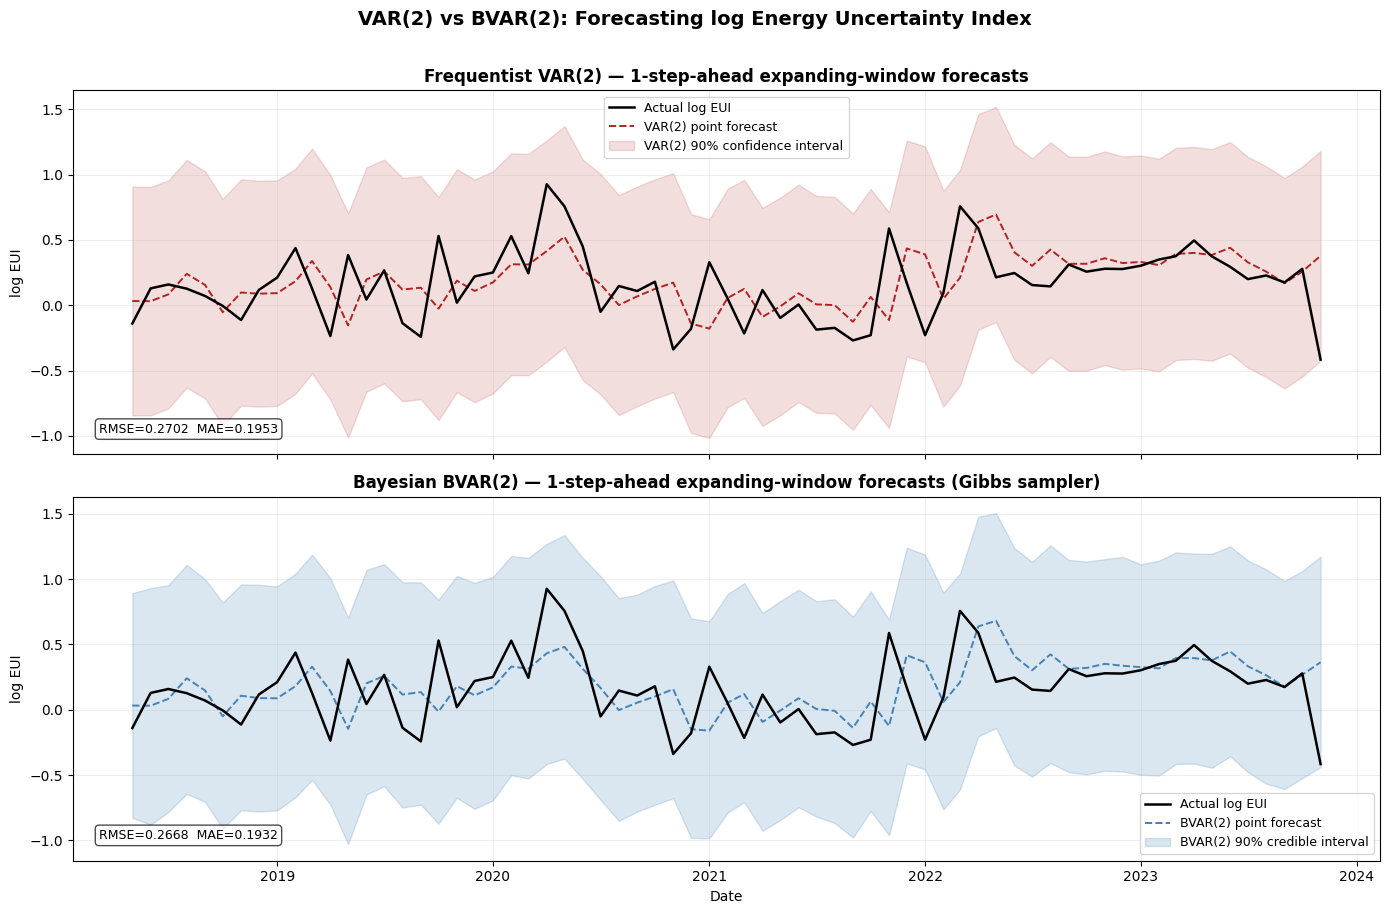

Figure saved to var_vs_bvar_forecast.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
var_p2_log_eui_fcast = pd.Series(var_p2_log_eui_fcast, index=actual.index)
# ── Top panel: Frequentist VAR ────────────────────────────────────────────────
ax = axes[0]
ax.plot(actual.index, actual.values, color="black", lw=1.8,
        label="Actual log EUI", zorder=5)
ax.plot(var_p2_log_eui_fcast.index, var_p2_log_eui_fcast.values,
        color="firebrick", lw=1.4, ls="--", label="VAR(2) point forecast")
ax.fill_between(
    var_p2_lower_series.index,
    var_p2_lower_series.values,
    var_p2_upper_series.values,
    color="firebrick", alpha=0.15, label="VAR(2) 90% confidence interval"
)
ax.set_title(
    "Frequentist VAR(2) — 1-step-ahead expanding-window forecasts",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_var = rmse(actual, var_p2_log_eui_fcast)
mae_var  = mae(actual, var_p2_log_eui_fcast)
ax.text(0.02, 0.06,
        f"RMSE={rmse_var:.4f}  MAE={mae_var:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# ── Bottom panel: Bayesian BVAR ───────────────────────────────────────────────
ax = axes[1]
ax.plot(actual.index, actual.values, color="black", lw=1.8,
        label="Actual log EUI", zorder=5)
ax.plot(bvar_forecast_series.index, bvar_forecast_series.values,
        color="steelblue", lw=1.4, ls="--", label="BVAR(2) point forecast")
ax.fill_between(
    bvar_lower_series.index,
    bvar_lower_series.values,
    bvar_upper_series.values,
    color="steelblue", alpha=0.20, label="BVAR(2) 90% credible interval"
)
ax.set_title(
    "Bayesian BVAR(2) — 1-step-ahead expanding-window forecasts (Gibbs sampler)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_bvar = rmse(actual, bvar_forecast_series)
mae_bvar  = mae(actual, bvar_forecast_series)
ax.text(0.02, 0.06,
        f"RMSE={rmse_bvar:.4f}  MAE={mae_bvar:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle(
    "VAR(2) vs BVAR(2): Forecasting log Energy Uncertainty Index",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()
print("Figure saved to var_vs_bvar_forecast.png")

### 3.4 Uncertainty width over time

Plotting the width of both intervals makes it easy to see whether the Bayesian
model shrinks or widens uncertainty relative to the frequentist approach,
especially during periods of high volatility (e.g. COVID-19, energy crises).

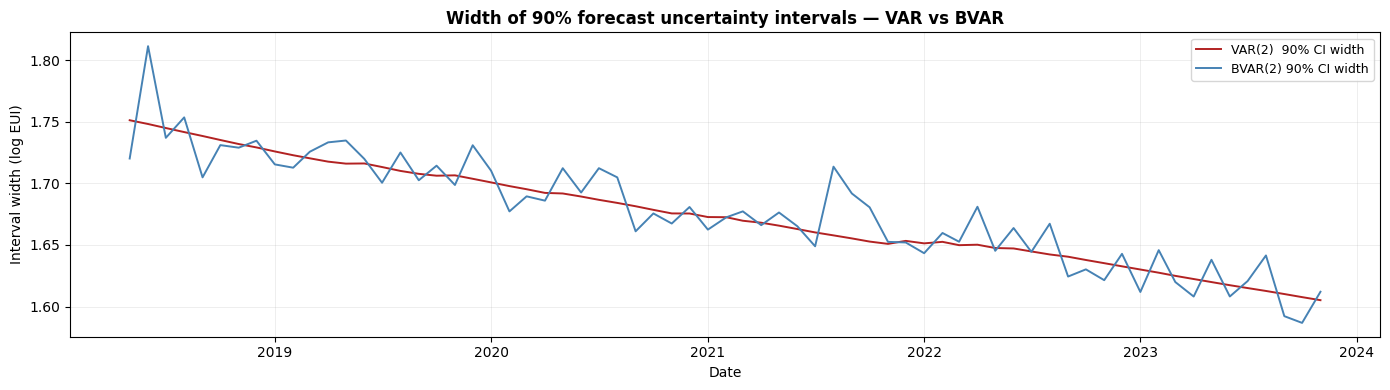

Mean VAR  CI width : 1.6747
Mean BVAR CI width : 1.6780


In [13]:
var_width  = var_p2_upper_series  - var_p2_lower_series
bvar_width = bvar_upper_series - bvar_lower_series

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(var_width.index,  var_width.values,
        color="firebrick",  lw=1.4, label="VAR(2)  90% CI width")
ax.plot(bvar_width.index, bvar_width.values,
        color="steelblue", lw=1.4, label="BVAR(2) 90% CI width")
ax.set_title(
    "Width of 90% forecast uncertainty intervals — VAR vs BVAR",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Interval width (log EUI)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Mean VAR  CI width : {var_width.mean():.4f}")
print(f"Mean BVAR CI width : {bvar_width.mean():.4f}")

In [14]:
from scipy.stats import norm as sp_norm

def crps_gaussian(actual: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    z     = (actual - mu) / sigma
    score = sigma * (z * (2 * sp_norm.cdf(z) - 1) + 2 * sp_norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(score))

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

actual       = test_df.loc[test_index, "log_eui"]
actual_level = np.exp(actual.values)

# ── VAR(2): σ in log space → level space via delta method ────────────────────
var_sigma_log   = (var_p2_upper_series.values - var_p2_lower_series.values) / (2 * sp_norm.ppf(0.95))
mu_var_level    = np.exp(var_p2_log_eui_forecast.values)
sigma_var_level = mu_var_level * var_sigma_log
crps_var_level  = crps_gaussian(actual_level, mu_var_level, sigma_var_level)

# ── BVAR(2): σ in log space → level space via delta method ───────────────────
bvar_sigma_log   = (bvar_upper_series.values - bvar_lower_series.values) / (2 * sp_norm.ppf(0.95))
mu_bvar_level    = np.exp(bvar_forecast_series.values)
sigma_bvar_level = mu_bvar_level * bvar_sigma_log
crps_bvar_level  = crps_gaussian(actual_level, mu_bvar_level, sigma_bvar_level)

# ── Metrics table (all in level space) ───────────────────────────────────────
metrics = pd.DataFrame(
    {
        "RMSE": [
            rmse(actual_level, np.exp(var_p2_log_eui_forecast)),
            rmse(actual_level, np.exp(bvar_forecast_series)),
        ],
        "MAE": [
            mae(actual_level, np.exp(var_p2_log_eui_forecast)),
            mae(actual_level, np.exp(bvar_forecast_series)),
        ],
        "CRPS": [crps_var_level, crps_bvar_level],
    },
    index=["VAR(2)", "BVAR(2)"],
)

print("Out-of-sample forecast accuracy (level space, test set)")
print("─" * 50)
print(metrics.to_string())
print()
winner_rmse = metrics["RMSE"].idxmin()
winner_mae  = metrics["MAE"].idxmin()
winner_crps = metrics["CRPS"].idxmin()
print(f"Lower RMSE  : {winner_rmse}")
print(f"Lower MAE   : {winner_mae}")
print(f"Lower CRPS  : {winner_crps}")

Out-of-sample forecast accuracy (level space, test set)
──────────────────────────────────────────────────
             RMSE       MAE      CRPS
VAR(2)   0.340715  0.238519  0.213860
BVAR(2)  0.336463  0.235932  0.212532

Lower RMSE  : BVAR(2)
Lower MAE   : BVAR(2)
Lower CRPS  : BVAR(2)


Running 4 independent chains for convergence diagnostics...
(This uses the full dataset, not the expanding window)

  Chain 1/4 complete (seed=42)
  Chain 2/4 complete (seed=7)
  Chain 3/4 complete (seed=13)
  Chain 4/4 complete (seed=99)

  Chains: 4  |  Post-burn draws: 8000  |  Parameters: 36

1. R-HAT (GELMAN-RUBIN)
  Max R-hat  : 1.0003  (threshold ≤ 1.01 strict, ≤ 1.05 lenient)
  Mean R-hat : 1.0000
  Parameters with R-hat > 1.01 : 0 / 36
  ✓ All R-hat ≤ 1.01

2. EFFECTIVE SAMPLE SIZE (bulk)
  Min ESS  : 29814  (threshold ≥ 400 per chain)
  Mean ESS : 31779
  Parameters with ESS < 400 : 0 / 36
  ✓ All ESS ≥ 400

3. TRACE PLOTS (6 key coefficients)


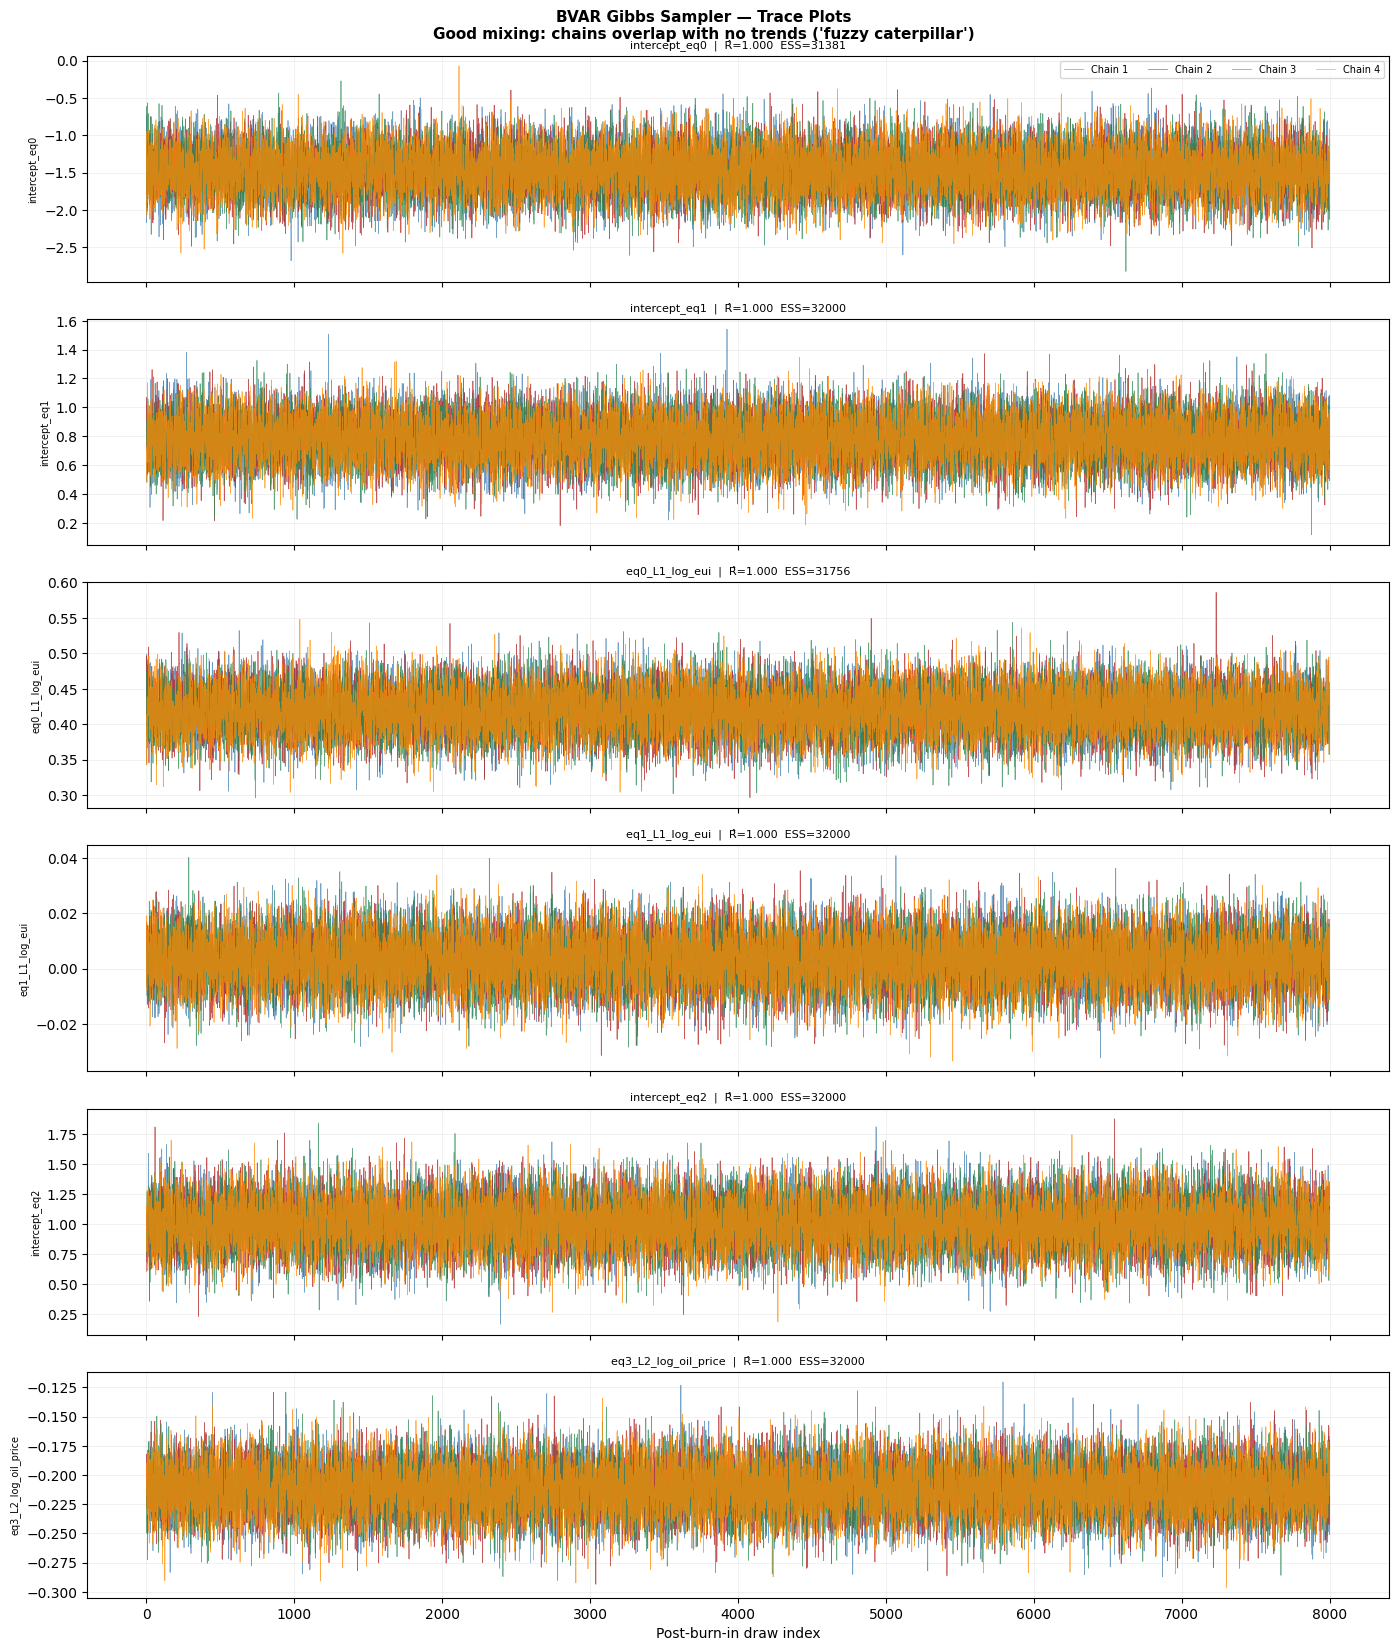

4. AUTOCORRELATION OF POSTERIOR DRAWS


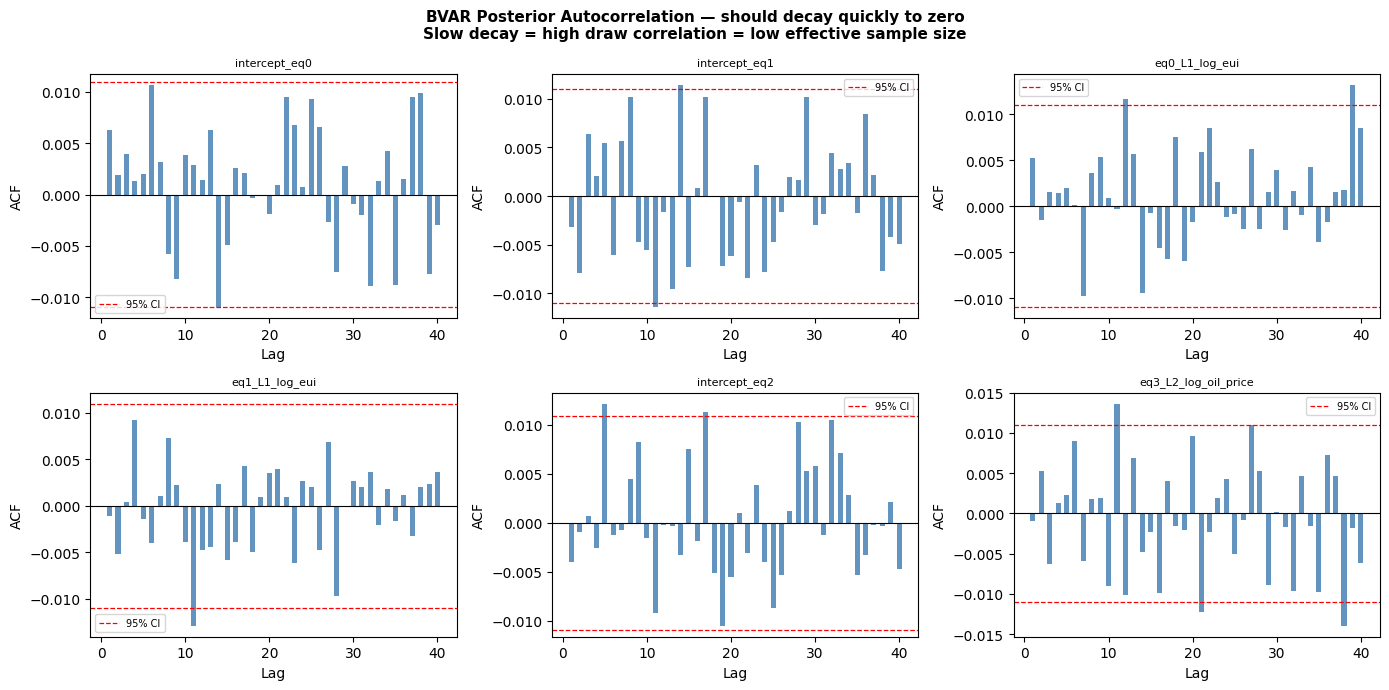

5. GEWEKE DIAGNOSTIC (Chain 1)
  |z| > 1.96 (p < 0.05): 0 / 36 parameters
  Max |z|               : 1.935
  ✓ No parameters failed Geweke test

6. RUNNING MEAN PLOTS — burn-in adequacy


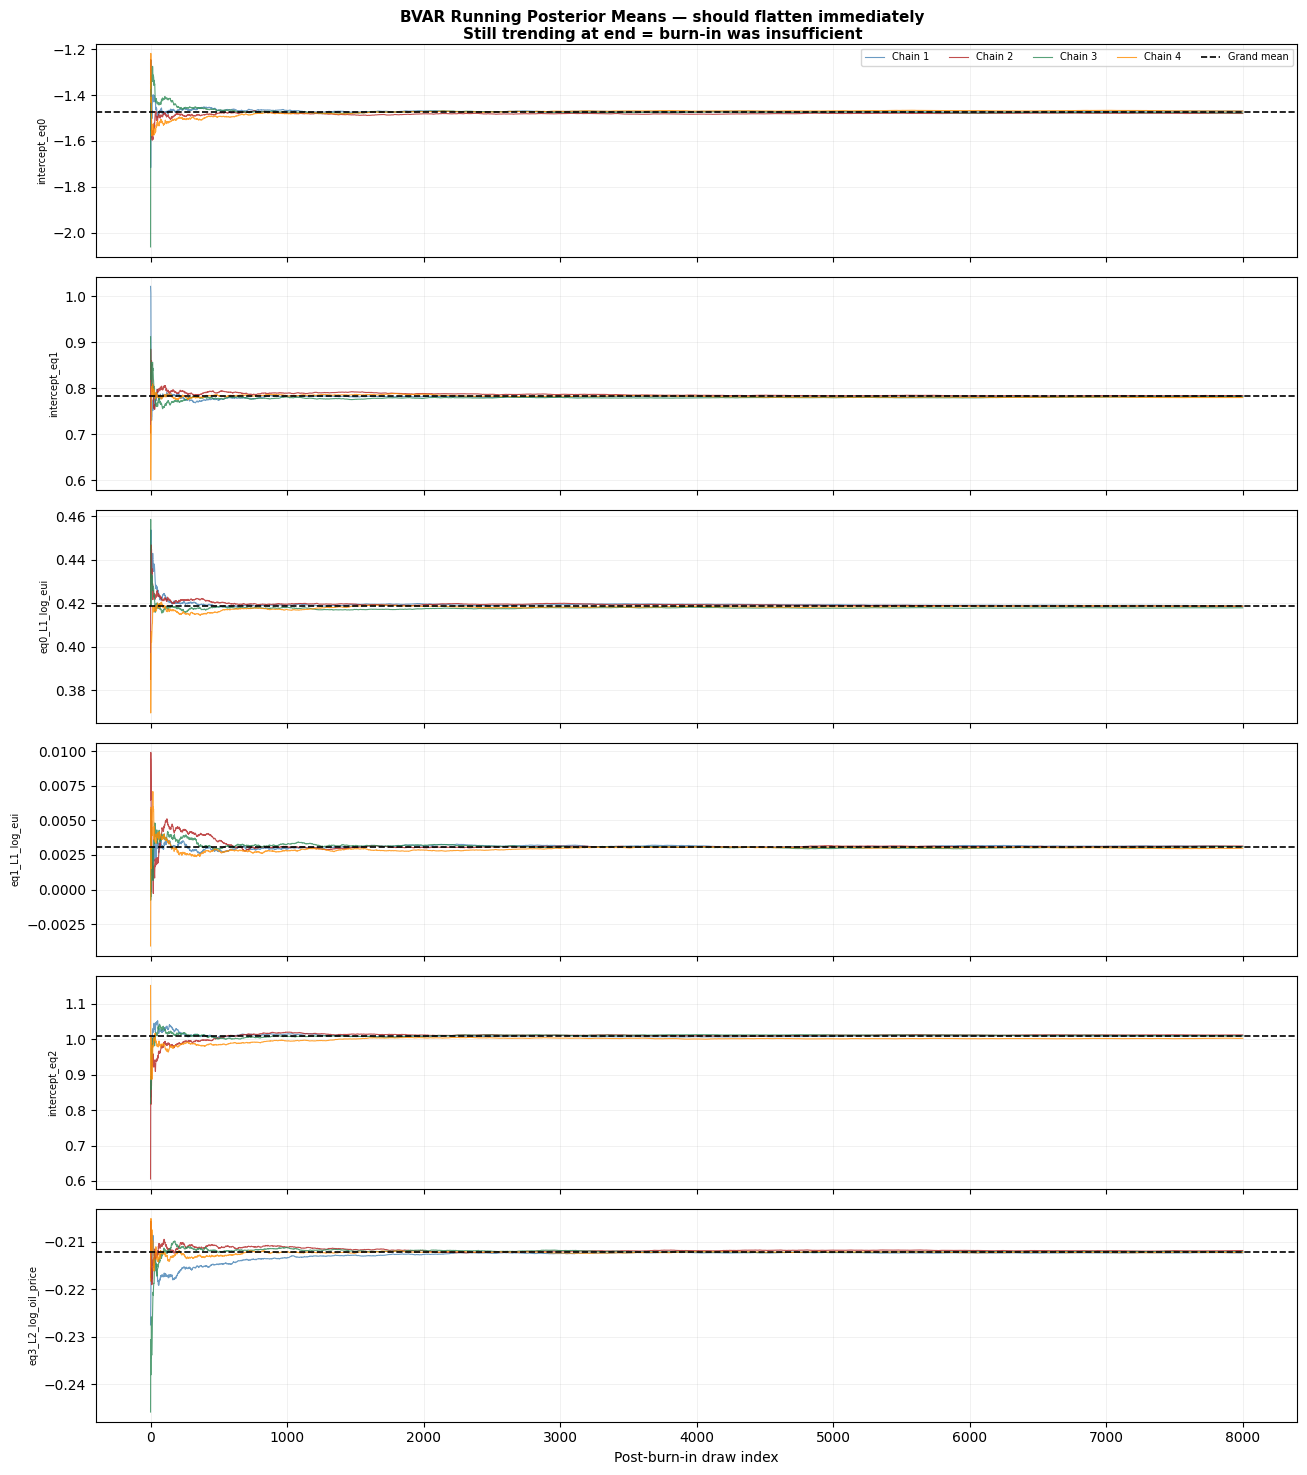

CODA SUMMARY — BVAR

  Parameters passing ALL checks : 36 / 36
  Parameters failing ≥ 1 check  : 0 / 36

  ✓ All parameters passed R-hat, ESS, and Geweke checks
  Gibbs sampler converged successfully.


In [15]:
# =============================================================================
# CODA CONVERGENCE DIAGNOSTICS — BVAR Gibbs Sampler
# =============================================================================
# Runs 4 independent chains on the full training sample and computes
# R-hat, ESS, trace plots, autocorrelation, Geweke, and running means.
# Requires: run_gibbs, build_XY, get_ols_start, beta0_mn, V_beta_inv_mn,
#           nu0, S0, endog_full, p, n, k, var_endog_cols
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 0. Run 4 independent chains on full sample ────────────────────────────────
print("Running 4 independent chains for convergence diagnostics...")
print("(This uses the full dataset, not the expanding window)\n")

N_DIAG   = 10_000
N_BURN_D =  2_000
N_CHAINS =  4
SEEDS    = [42, 7, 13, 99]   # intentionally different starting points

data_diag = endog_full.values
Y_d, X_d  = build_XY(data_diag, p)

chain_betas  = []
chain_sigmas = []

for idx, seed in enumerate(SEEDS):
    rng_d = np.random.default_rng(seed)
    # Overdispersed start: perturb OLS estimates differently per chain
    b0, S0_d = get_ols_start(data_diag, p)
    b0_perturbed = b0 + rng_d.normal(0, 0.5, size=b0.shape)

    b_draws, s_draws = run_gibbs(
        Y=Y_d, X=X_d,
        beta0=beta0_mn, V_beta_inv=V_beta_inv_mn,
        nu0=nu0, S0=S0,
        N_draws=N_DIAG,
        beta_start=b0_perturbed,
        Sigma_start=S0_d,
        rng=rng_d,
    )
    chain_betas.append(b_draws[N_BURN_D:])    # (n_keep, nk)
    chain_sigmas.append(s_draws[N_BURN_D:])   # (n_keep, n, n)
    print(f"  Chain {idx+1}/4 complete (seed={seed})")

chain_betas  = np.stack(chain_betas,  axis=0)  # (4, n_keep, nk)
chain_sigmas = np.stack(chain_sigmas, axis=0)  # (4, n_keep, n, n)
n_keep = chain_betas.shape[1]
nk     = chain_betas.shape[2]
print(f"\n  Chains: {N_CHAINS}  |  Post-burn draws: {n_keep}  |  Parameters: {nk}")

# ── Build parameter labels ────────────────────────────────────────────────────
param_labels = []
for eq in range(n):
    param_labels.append(f"intercept_eq{eq}")
    for lag in range(1, p + 1):
        for var in range(n):
            param_labels.append(f"eq{eq}_L{lag}_{var_endog_cols[var]}")

# ── 1. R-hat (Gelman-Rubin) ───────────────────────────────────────────────────
def gelman_rubin(chains):
    """chains: (n_chains, n_draws) for one scalar parameter."""
    M, N = chains.shape
    chain_means = chains.mean(axis=1)
    grand_mean  = chain_means.mean()
    B = N / (M - 1) * np.sum((chain_means - grand_mean) ** 2)
    W = np.mean(chains.var(axis=1, ddof=1))
    var_hat = (N - 1) / N * W + B / N
    return np.sqrt(var_hat / W)

print("\n" + "=" * 60)
print("1. R-HAT (GELMAN-RUBIN)")
print("=" * 60)

rhats = np.array([
    gelman_rubin(chain_betas[:, :, j]) for j in range(nk)
])
rhat_df = pd.DataFrame({"parameter": param_labels, "R-hat": rhats.round(4)})

print(f"  Max R-hat  : {rhats.max():.4f}  (threshold ≤ 1.01 strict, ≤ 1.05 lenient)")
print(f"  Mean R-hat : {rhats.mean():.4f}")
print(f"  Parameters with R-hat > 1.01 : {(rhats > 1.01).sum()} / {nk}")

if (rhats > 1.01).any():
    print("\n  ⚠ Parameters failing R-hat ≤ 1.01:")
    print(rhat_df[rhats > 1.01].to_string(index=False))
else:
    print("  ✓ All R-hat ≤ 1.01")

# ── 2. Effective Sample Size ───────────────────────────────────────────────────
def ess_bulk(chains):
    """Rank-normalised bulk ESS. chains: (n_chains, n_draws)."""
    from scipy.stats import rankdata
    M, N  = chains.shape
    ranks = rankdata(chains.flatten()).reshape(M, N)
    z     = (ranks - 0.5) / (M * N)
    M2, N2 = z.shape
    rho = []
    combined_var = z.var(ddof=1)
    if combined_var == 0:
        return float(M2 * N2)
    for t in range(1, N2 // 2):
        ac = np.mean([np.cov(c[:-t], c[t:])[0, 1] for c in z]) / combined_var
        if ac < 0:
            break
        rho.append(ac)
    return M2 * N2 / (1 + 2 * sum(rho))

print("\n" + "=" * 60)
print("2. EFFECTIVE SAMPLE SIZE (bulk)")
print("=" * 60)

ess_vals = np.array([ess_bulk(chain_betas[:, :, j]) for j in range(nk)])
ess_df   = pd.DataFrame({"parameter": param_labels,
                          "ESS_bulk": ess_vals.astype(int)})

print(f"  Min ESS  : {ess_vals.min():.0f}  (threshold ≥ 400 per chain)")
print(f"  Mean ESS : {ess_vals.mean():.0f}")
print(f"  Parameters with ESS < 400 : {(ess_vals < 400).sum()} / {nk}")

if (ess_vals < 400).any():
    print("\n  ⚠ Parameters with low ESS:")
    print(ess_df[ess_vals < 400].to_string(index=False))
else:
    print("  ✓ All ESS ≥ 400")

# ── 3. Trace plots — 6 representative coefficients ────────────────────────────
print("\n" + "=" * 60)
print("3. TRACE PLOTS (6 key coefficients)")
print("=" * 60)

# Pick: intercepts of eq0 and eq1, own-lag-1 of eq0 and eq1, plus two cross-lags
key_idx = [0, k, 1, k + 1, nk // 2, nk - 1]
key_lbl = [param_labels[j] for j in key_idx]
colors  = ["steelblue", "firebrick", "seagreen", "darkorange"]

fig, axes = plt.subplots(len(key_idx), 1,
                          figsize=(14, 2.8 * len(key_idx)), sharex=True)

for ax, j, lbl in zip(axes, key_idx, key_lbl):
    for c_idx in range(N_CHAINS):
        ax.plot(chain_betas[c_idx, :, j],
                lw=0.5, alpha=0.75, color=colors[c_idx],
                label=f"Chain {c_idx+1}")
    ax.set_ylabel(lbl, fontsize=7)
    ax.set_title(f"{lbl}  |  R̂={rhats[j]:.3f}  ESS={int(ess_vals[j])}",
                 fontsize=8)
    if j == key_idx[0]:
        ax.legend(fontsize=7, ncol=4, loc="upper right")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Post-burn-in draw index")
fig.suptitle(
    "BVAR Gibbs Sampler — Trace Plots\n"
    "Good mixing: chains overlap with no trends ('fuzzy caterpillar')",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── 4. Autocorrelation plots ───────────────────────────────────────────────────
print("=" * 60)
print("4. AUTOCORRELATION OF POSTERIOR DRAWS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
max_lag = 40
n_total = N_CHAINS * n_keep

for ax, j, lbl in zip(axes, key_idx, key_lbl):
    pooled  = chain_betas[:, :, j].flatten()
    acf_vals = [
        np.corrcoef(pooled[:-lag], pooled[lag:])[0, 1]
        for lag in range(1, max_lag + 1)
    ]
    ax.bar(range(1, max_lag + 1), acf_vals,
           color="steelblue", width=0.6, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ci = 1.96 / np.sqrt(n_total)
    ax.axhline( ci, color="red", lw=0.9, ls="--", label="95% CI")
    ax.axhline(-ci, color="red", lw=0.9, ls="--")
    ax.set_title(lbl, fontsize=8)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.legend(fontsize=7)

fig.suptitle(
    "BVAR Posterior Autocorrelation — should decay quickly to zero\n"
    "Slow decay = high draw correlation = low effective sample size",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── 5. Geweke test ────────────────────────────────────────────────────────────
print("=" * 60)
print("5. GEWEKE DIAGNOSTIC (Chain 1)")
print("=" * 60)

def geweke_z(chain, first=0.1, last=0.5):
    n = len(chain)
    a = chain[:int(first * n)]
    b = chain[int((1 - last) * n):]
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    return (a.mean() - b.mean()) / se if se > 0 else 0.0

geweke_zs = np.array([geweke_z(chain_betas[0, :, j]) for j in range(nk)])

print(f"  |z| > 1.96 (p < 0.05): {(np.abs(geweke_zs) > 1.96).sum()} / {nk} parameters")
print(f"  Max |z|               : {np.abs(geweke_zs).max():.3f}")

if (np.abs(geweke_zs) > 1.96).any():
    print("\n  ⚠ Parameters failing Geweke test:")
    fail_idx = np.where(np.abs(geweke_zs) > 1.96)[0]
    for j in fail_idx:
        print(f"    {param_labels[j]:<35}  z = {geweke_zs[j]:.3f}")
else:
    print("  ✓ No parameters failed Geweke test")

# ── 6. Running mean plots ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("6. RUNNING MEAN PLOTS — burn-in adequacy")
print("=" * 60)

fig, axes = plt.subplots(len(key_idx), 1,
                          figsize=(13, 2.5 * len(key_idx)), sharex=True)

for ax, j, lbl in zip(axes, key_idx, key_lbl):
    for c_idx in range(N_CHAINS):
        draws = chain_betas[c_idx, :, j]
        running_mean = np.cumsum(draws) / np.arange(1, len(draws) + 1)
        ax.plot(running_mean, lw=0.8, alpha=0.8,
                color=colors[c_idx], label=f"Chain {c_idx+1}")
    ax.axhline(chain_betas[:, :, j].mean(), color="black",
               lw=1.2, ls="--", label="Grand mean")
    ax.set_ylabel(lbl, fontsize=7)
    ax.grid(True, alpha=0.25)
    if j == key_idx[0]:
        ax.legend(fontsize=7, ncol=5, loc="upper right")

axes[-1].set_xlabel("Post-burn-in draw index")
fig.suptitle(
    "BVAR Running Posterior Means — should flatten immediately\n"
    "Still trending at end = burn-in was insufficient",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── 7. Summary table ──────────────────────────────────────────────────────────
print("=" * 60)
print("CODA SUMMARY — BVAR")
print("=" * 60)

summary_df = pd.DataFrame({
    "parameter": param_labels,
    "R-hat":     rhats.round(4),
    "ESS_bulk":  ess_vals.astype(int),
    "Geweke_z":  geweke_zs.round(3),
    "Rhat_ok":   rhats <= 1.05,
    "ESS_ok":    ess_vals >= 400,
    "Geweke_ok": np.abs(geweke_zs) <= 1.96,
})

all_ok = summary_df[["Rhat_ok", "ESS_ok", "Geweke_ok"]].all(axis=1)
print(f"\n  Parameters passing ALL checks : {all_ok.sum()} / {nk}")
print(f"  Parameters failing ≥ 1 check  : {(~all_ok).sum()} / {nk}")

if (~all_ok).any():
    print("\n  ⚠ Parameters with at least one diagnostic failure:")
    print(summary_df[~all_ok][
        ["parameter", "R-hat", "ESS_bulk", "Geweke_z"]
    ].to_string(index=False))
else:
    print("\n  ✓ All parameters passed R-hat, ESS, and Geweke checks")
    print("  Gibbs sampler converged successfully.")